In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)
df_eval = pd.read_csv("data/extrait_eval.csv")
df_eval["id_employee"] = df_eval['eval_number'].str.replace('E_', '')
df_eval.drop('eval_number', axis=1, inplace=True)
df_eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,id_employee
0,2,3,2,4,1,1,3,Oui,11 %,1
1,3,2,2,2,4,3,4,Non,23 %,2
2,4,2,1,3,2,3,3,Oui,15 %,4
3,4,3,1,3,3,3,3,Oui,11 %,5
4,1,3,1,2,4,3,3,Non,12 %,7


In [4]:
df_sirh = pd.read_csv("data/extrait_sirh.csv")
df_sirh["id_employee"] = df_sirh["id_employee"].astype(str)
df_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [5]:
df_merge_temp = df_sirh.merge(df_eval, how = "inner", on = ["id_employee"])
df_merge_temp.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %


In [6]:
df_sondage = pd.read_csv("data/extrait_sondage.csv")
df_sondage['id_employee'] = df_sondage['code_sondage'].astype(str)
df_sondage.drop('code_sondage', axis=1, inplace=True)
df_sondage.head()
#print(str(df_sondage['code_sondage']))

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,id_employee
0,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7,2
2,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0,4
3,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0,5
4,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2,7


In [7]:
df_merge = df_merge_temp.merge(df_sondage, how = "inner", on = ["id_employee"])

In [8]:
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


<Axes: >

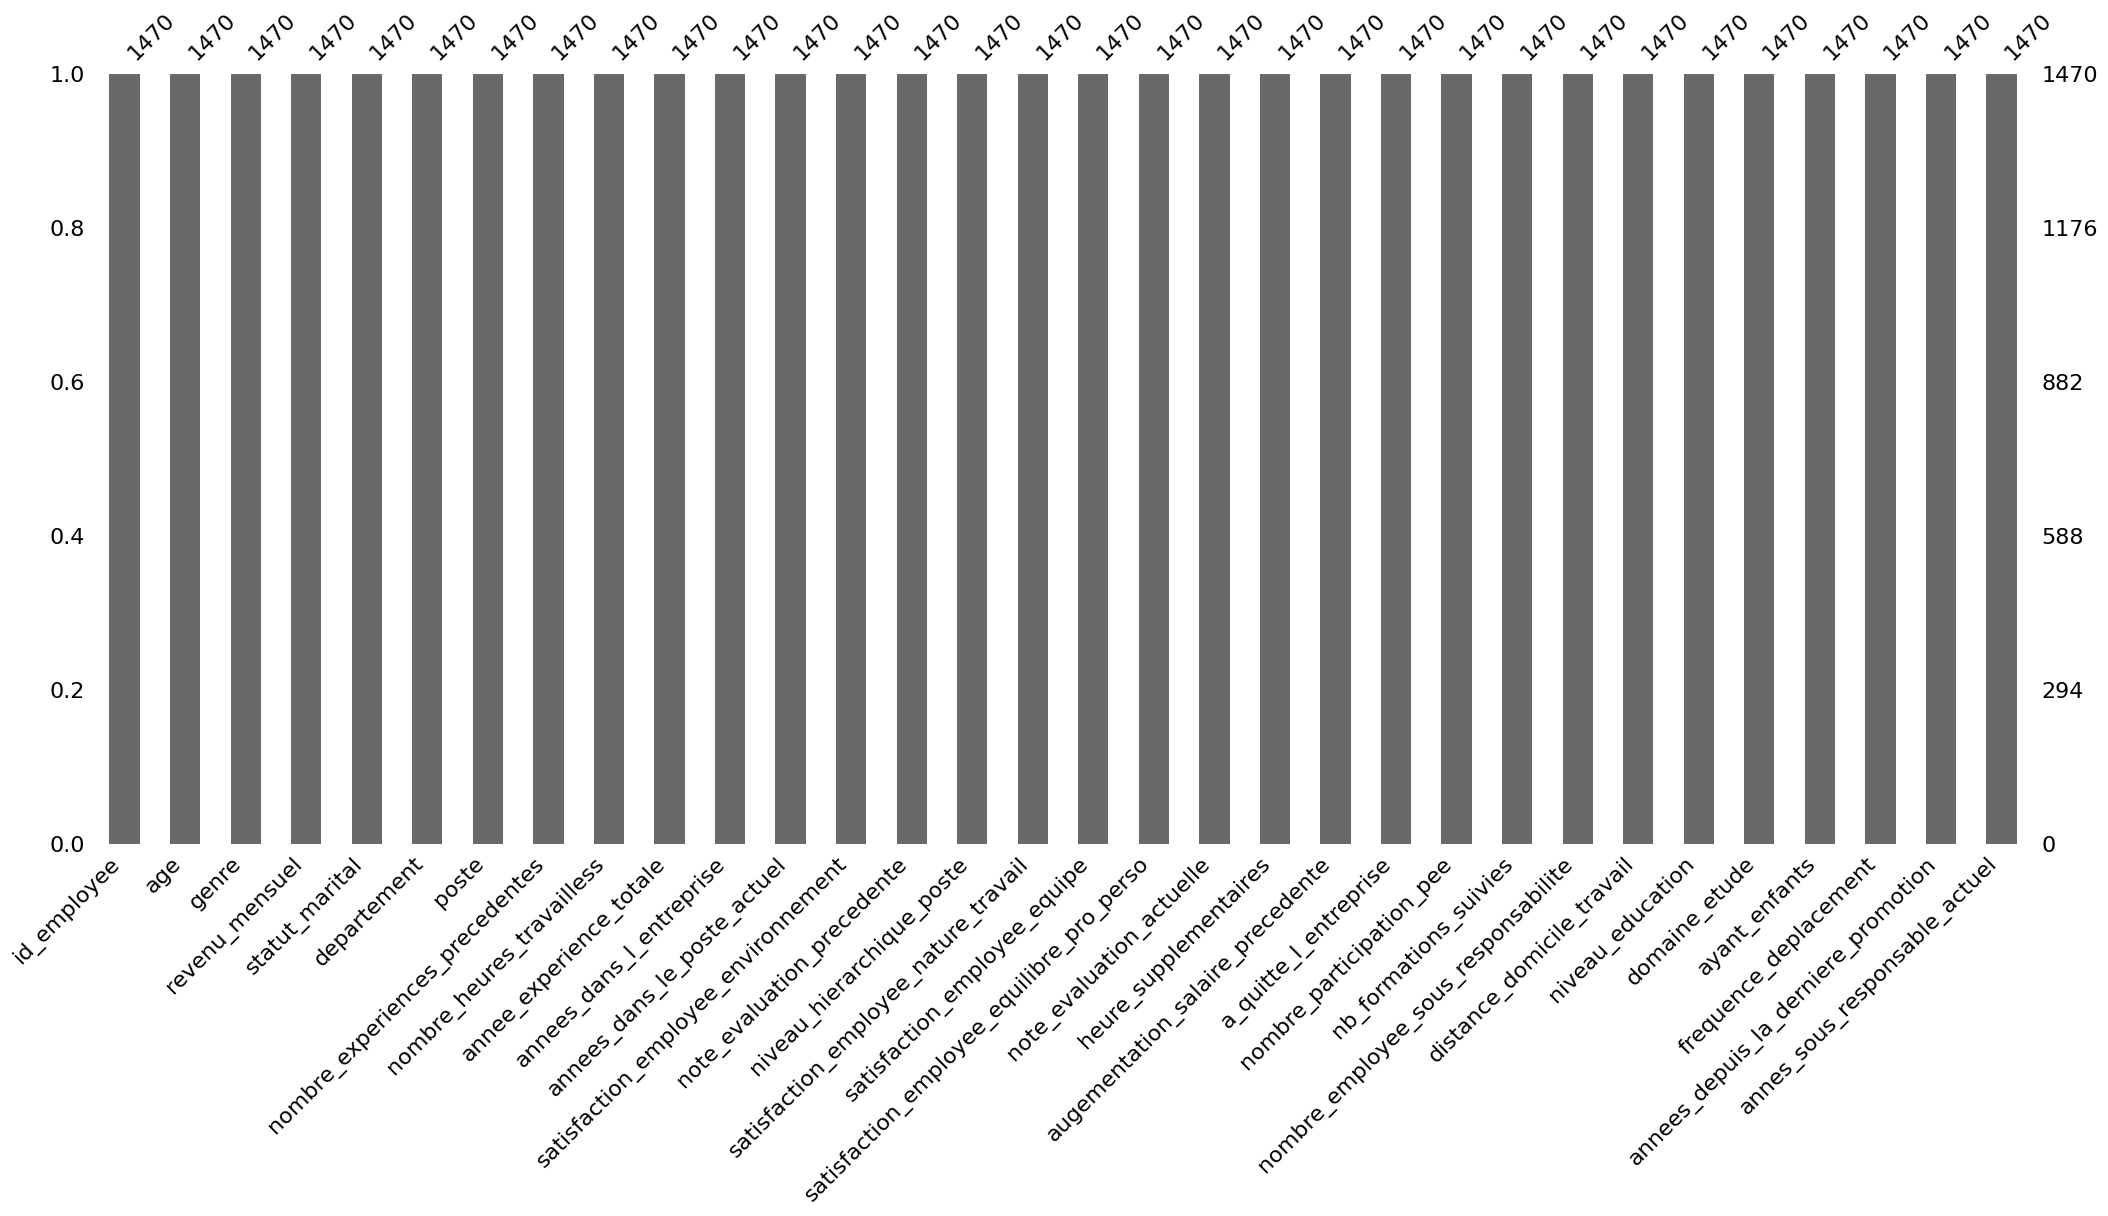

In [9]:
msno.bar(df_merge)

In [10]:
df_merge['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

In [11]:
df_merge['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [12]:
df_merge['poste'].value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [13]:
df_merge['domaine_etude'].value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

In [14]:
def make_countplot(df, x_axis, y_axis):
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=x_axis, hue=y_axis, data=df)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.legend_.set_title("A quitté l'entreprise \n (Oui : 1 / Non : 0)")

<Axes: xlabel='a_quitte_l_entreprise', ylabel='count'>

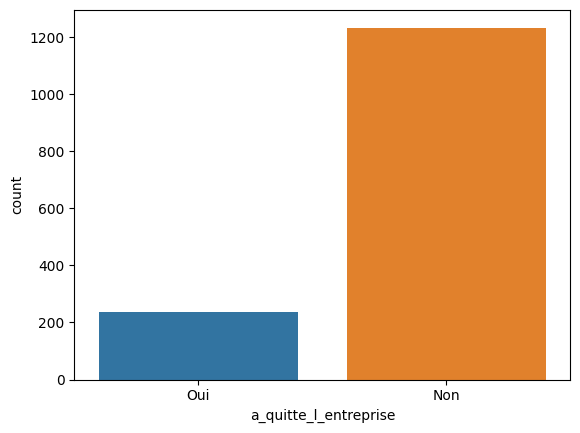

In [19]:
sns.countplot(data=df_merge, x="a_quitte_l_entreprise", hue="a_quitte_l_entreprise")


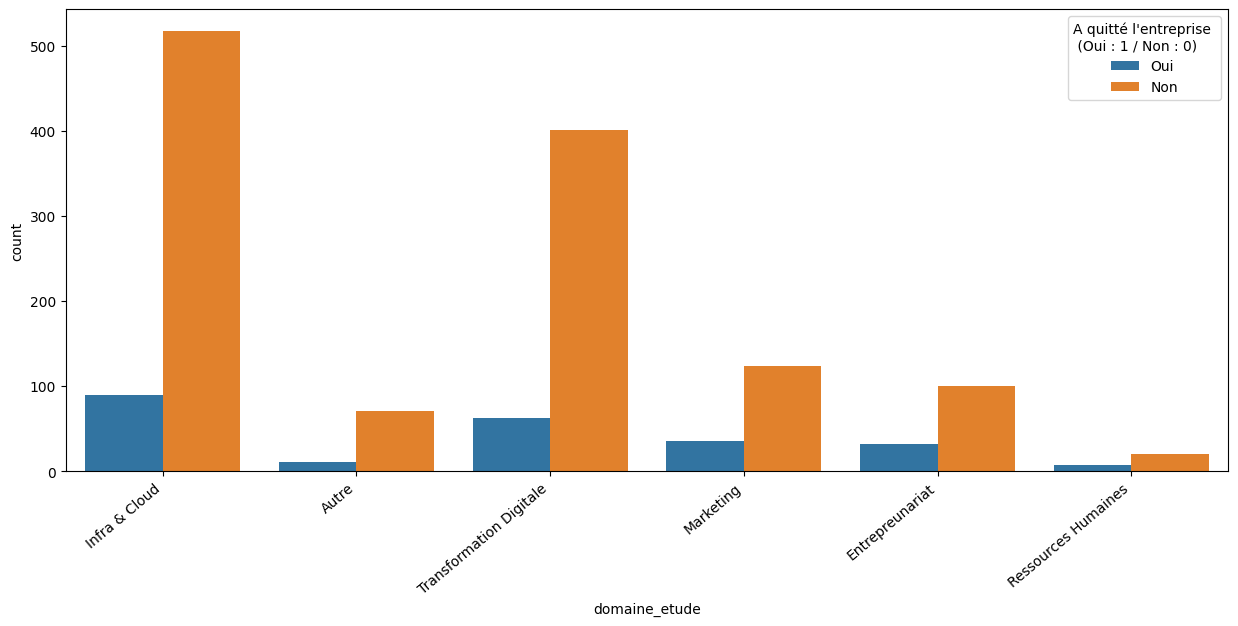

In [14]:
make_countplot(df_merge, "domaine_etude", "a_quitte_l_entreprise")

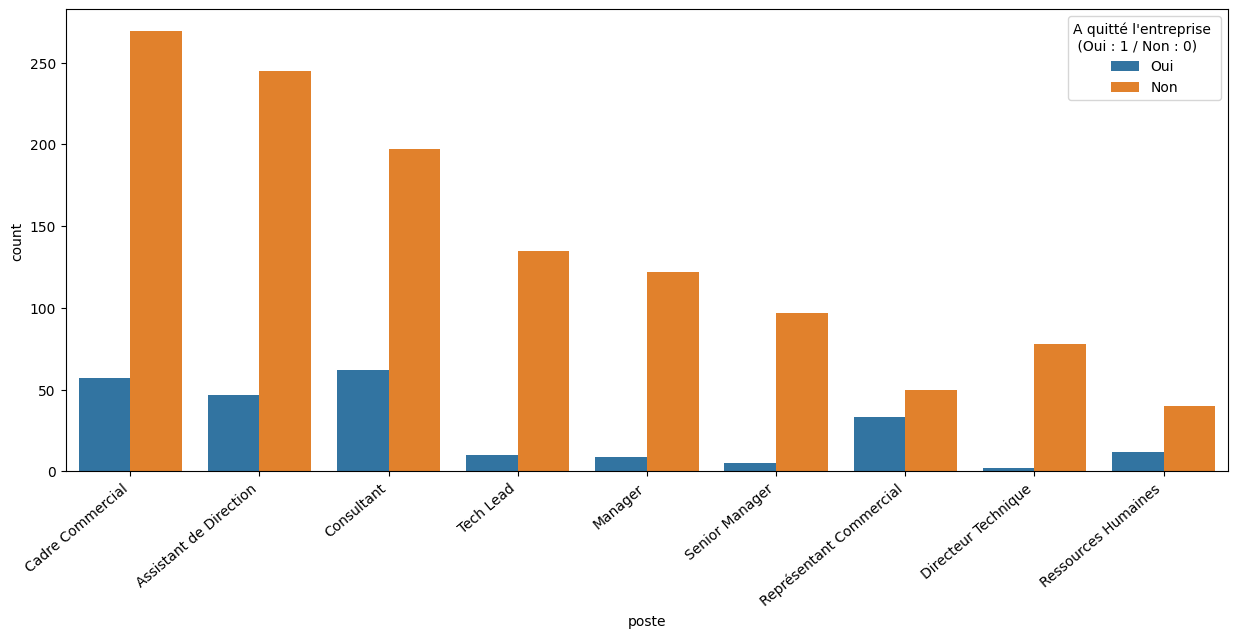

In [15]:
make_countplot(df_merge, "poste", "a_quitte_l_entreprise")

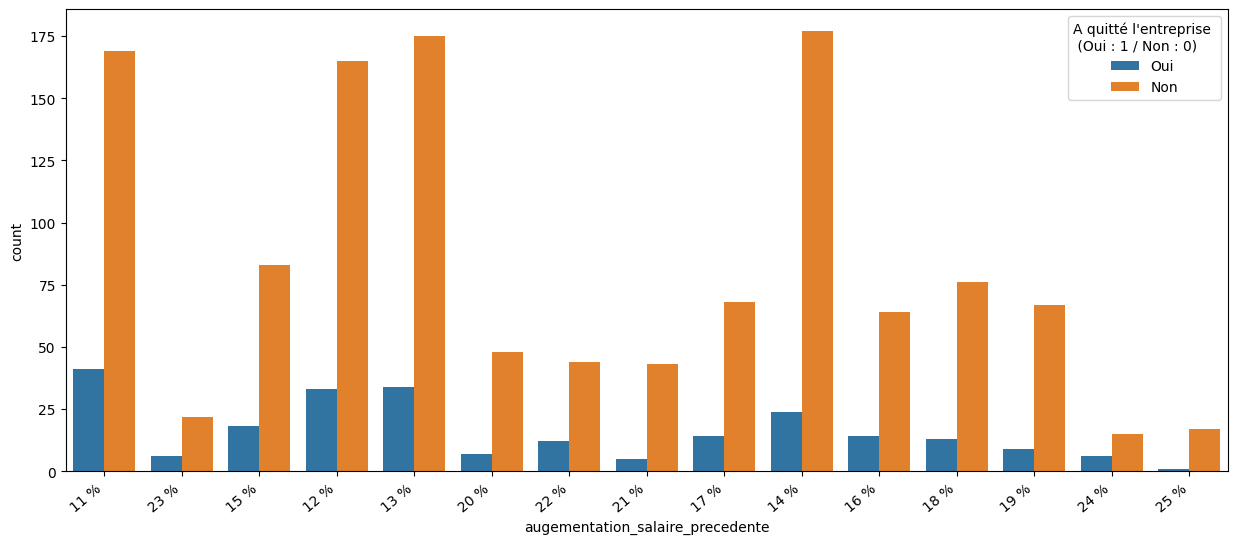

In [16]:
make_countplot(df_merge, "augementation_salaire_precedente", "a_quitte_l_entreprise")

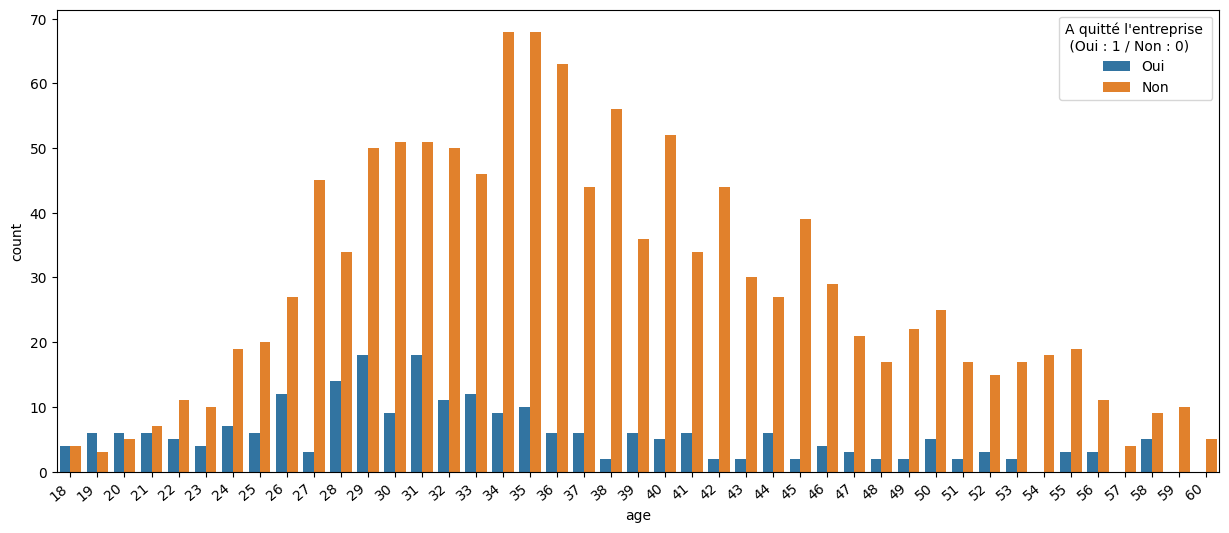

In [17]:
make_countplot(df_merge, "age", "a_quitte_l_entreprise")

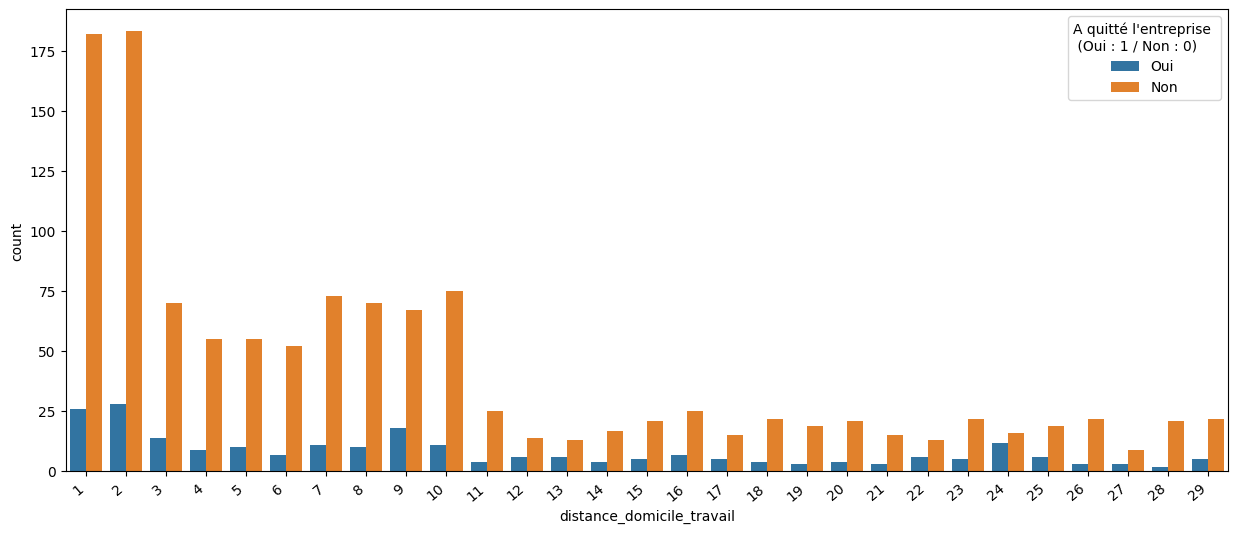

In [18]:
make_countplot(df_merge, "distance_domicile_travail", "a_quitte_l_entreprise")

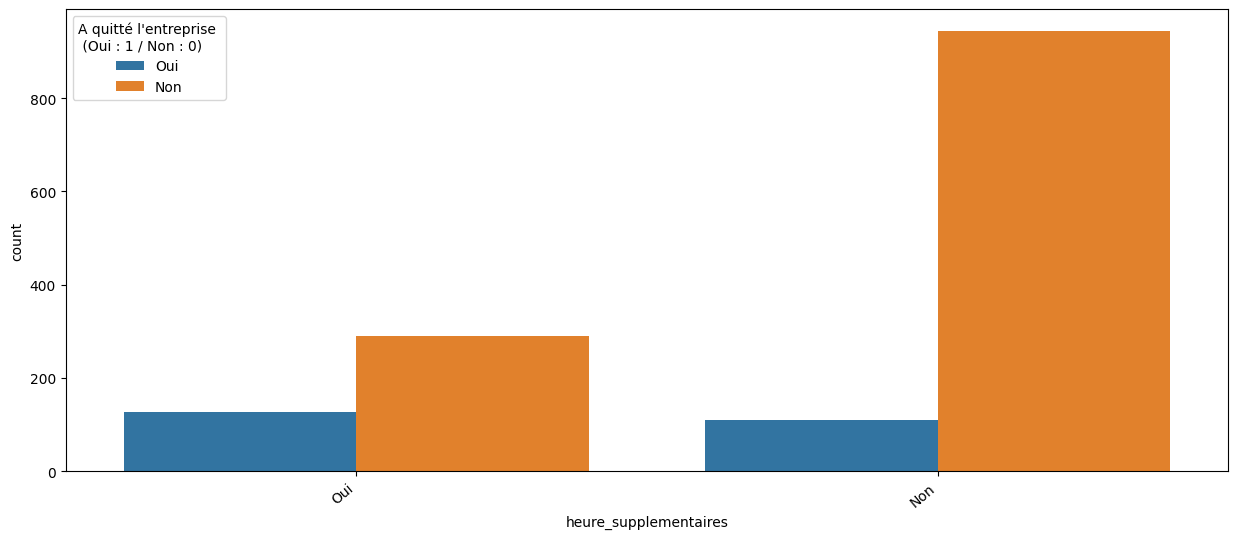

In [19]:
make_countplot(df_merge, "heure_supplementaires", "a_quitte_l_entreprise")

In [20]:
df_merge.to_csv("processed/data_merge.csv")